# Aggregate the OGGM v1.6.3 rgiv62 raw files to regional or global summed up csv files


*Note that the paths of this notebook only work if you are running the notebook from the OGGM cluster*


In [27]:
import xarray as xr
import pandas as pd
import progressbar
import numpy as np
from oggm.utils import mkdir
import matplotlib.pyplot as plt
import json
import os

In [28]:
%pwd

'/home/www/oggm/oggm-standard-projections/oggm-standard-projections-csv-files/notebooks/1.6.3'

In [35]:
rgi_version = 'rgi62'


In [36]:
dirpath = '/home/www/oggm/oggm-standard-projections/oggm_v16/2025.6/'
outputpath = '/home/www/oggm/oggm-standard-projections/oggm-standard-projections-csv-files/1.6.3'
# for OGGM v1.6.3, we only ran `w5e5_gcm_merged` 
# (i.e., w5e5 until end of 2019, and the climate models from thereon)

oggm_version = 'oggm_v1.6.3_2025.6'

baseline_climate = 'w5e5'
historical_future_option = f'{baseline_climate}_gcm_merged'

exp = 'regional_spinup'  # this is actually the same as "match_geod_pergla" (if the dynamic spinup gdirs are used)
## new for OGGM v1.6.3 --> additional experiments
dirpath = dirpath + f'{baseline_climate}/{exp}/'
outputpath = outputpath + f'/{baseline_climate}/{exp}'



In [37]:
mkdir(outputpath + '/common_running_2100')

'/home/www/oggm/oggm-standard-projections/oggm-standard-projections-csv-files/1.6.3/w5e5/regional_spinup/common_running_2100'

## A. Common running glacier aggregations for all projections (and options) until 2100, i.e. `common_running_2100`

### B. 1: GCMs - missing glaciers overview  

In [38]:
allfiles_rgi70G = []
allfiles_rgi62 = []

for root, dirs, files in os.walk(dirpath):
    if not '/2300/' in root:
        for file in files:
            if (file.endswith(".nc")) and ('run_hydro' in file) and (historical_future_option in file) and ('_0_1000' in file) and ('basin' not in file):
                _p = os.path.join(root, file)
                if ('ssp126' in _p) or ('ssp370' in _p) or ('ssp585' in _p):
                    if '2000-v7.0-G' in _p:
                        allfiles_rgi70G.append(_p)
                    else:
                        allfiles_rgi62.append(_p)

if rgi_version == 'rgi62':
    rgi_meta = pd.read_hdf('/home/www/oggm/rgi/rgi62_stats.h5')
    rgi_meta = rgi_meta.loc[rgi_meta.Connect != 2]
    allfiles = allfiles_rgi62G
else:
    rgi_meta = pd.read_csv('/home/www/oggm/rgi/RGI2000-v7.0-G-global-attributes.csv')
    rgi_meta = rgi_meta.loc[rgi_meta.conn_lvl !=2]
    rgi_meta['O1Region'] = rgi_meta['o1region'].astype(str).str.zfill(2)
    rgi_meta['Area'] = rgi_meta['area_km2']
    rgi_meta = rgi_meta.set_index('rgi_id')
    allfiles = allfiles_rgi70G

add='_only_one_gcm' # because just one GCM

df_meta = pd.DataFrame()
invalid_per_reg = {}  
meta_per_reg = {}

In [39]:
assert len(allfiles_rgi70G) == 3*18 # rgi19 is missing
assert len(allfiles_rgi62G) == 3*19 # rgi19 is missing

In [40]:
rgi_version

'rgi62'

In [41]:
# this takes very long !!!
invalid_per_reg = {}  
meta_per_reg = {}
for f in allfiles: #progressbar.progressbar(allfiles):
    ename = f.replace(dirpath, '')
    ss = ename.split('/')
    cmip = ss[0]
    endyr = ss[1]
    rgi_reg = ss[2]
    gcm_original = ss[3].split('_')[5] 
    gcm = gcm_original.upper()
    if 'ISIMIP3b' in cmip:
        ssp = ss[3].split('_')[7]
        bc = 'ISIMIP3b:1979-2014'
    else:
        ssp = ss[3].split('_')[6]
        bc = '2000-2019'

    end0,end1 = ss[3].split('_')[-2:]
    end = end0+'_'+end1
    ff = f[:-len(end)]+'*'

    # exp is the same everywhere, so we don't need it as an id... 
    run_id = f'{cmip}:{endyr}:{gcm}:{ssp}:{rgi_reg}'
    df_meta.loc[run_id, 'cmip'] = cmip
    df_meta.loc[run_id, 'gcm_original'] = gcm_original # some have lower and upper cases in the raw output files
    df_meta.loc[run_id, 'gcm'] = gcm  # for the aggregated files, all GCMs are in upper cases
    df_meta.loc[run_id, 'scenario'] = ssp
    df_meta.loc[run_id, 'rgi_reg'] = rgi_reg
    df_meta.loc[run_id, 'end_year'] = 'nan'  # changed from 0 to this, to remove warning,--> will be filled later
    df_meta.loc[run_id, 'bias_correction'] = bc
    df_meta.loc[run_id, 'perc_area_missing'] = 0
    df_meta.loc[run_id, 'fpath'] = ff
    
    if rgi_reg not in invalid_per_reg:
        invalid_per_reg[rgi_reg] = set()
    
    if rgi_reg not in meta_per_reg:
        meta_per_reg[rgi_reg] = rgi_meta.loc[rgi_meta['O1Region'] == rgi_reg[-2:]]
    
    with xr.open_mfdataset(ff) as ds:
        ds_t = ds.isel(time=-1).volume.load()
    df_meta.loc[run_id, 'end_year'] = str(int(ds_t.time))
    missing_ids = ds_t.rgi_id[ds_t.isnull()].data
    perc = meta_per_reg[rgi_reg].loc[missing_ids]['Area'].sum() / meta_per_reg[rgi_reg]['Area'].sum() 
    df_meta.loc[run_id, 'perc_area_missing'] = perc
    invalid_per_reg[rgi_reg] = invalid_per_reg[rgi_reg].union(missing_ids)
    #if f == allfiles[100]:
    #    print(f)
df_meta['exp'] = exp
df_meta['historical_future_option'] = historical_future_option
df_meta['oggm_version'] = oggm_version
df_meta.to_csv(f'{outputpath}/common_running_2100/metadata_{rgi_version}{add}.csv')

In [42]:
dds = df_meta.sort_values('perc_area_missing', ascending=False)
dds[dds['perc_area_missing'] > 0.01].rgi_reg.unique()

array(['RGI12', 'RGI10'], dtype=object)

In [43]:
for k, v in invalid_per_reg.items():
    invalid_per_reg[k] = list(v)
with open(f'{outputpath}/common_running_2100/rgi_ids_missing_{rgi_version}{add}.json', 'w') as f:
    json.dump(invalid_per_reg, f)

# these are now the common running glaciers over all scenarios and GCMs and all cmip variants going until 2100 or until 2300
odf = pd.DataFrame()
for rgi_reg, missing_ids in invalid_per_reg.items():
    odf.loc[rgi_reg, 'n_glaciers'] = len(meta_per_reg[rgi_reg])
    odf.loc[rgi_reg, 'n_missing_glaciers'] = len(missing_ids)
    odf.loc[rgi_reg, 'rgi_area_km2'] = meta_per_reg[rgi_reg]['Area'].sum() 
    odf.loc[rgi_reg, 'missing_area_km2'] = meta_per_reg[rgi_reg].loc[missing_ids]['Area'].sum()
    odf.loc[rgi_reg, 'missing_area_perc'] = odf.loc[rgi_reg, 'missing_area_km2'] / odf.loc[rgi_reg, 'rgi_area_km2']
odf[['n_glaciers', 'n_missing_glaciers']] = odf[['n_glaciers', 'n_missing_glaciers']].astype(int)
odf = odf.sort_values(by='missing_area_perc', ascending=False)
odf

,n_glaciers,n_missing_glaciers,rgi_area_km2,missing_area_km2,missing_area_perc
RGI12,1888,339,1306.992,155.814,0.119216
RGI10,5151,141,2410.051,86.194,0.035764
RGI16,2939,28,2341.036,16.329,0.006975
RGI02,18855,555,14524.224,27.581,0.001899
RGI19,2752,396,132867.219,113.011,0.000851
RGI11,3927,59,2092.146,1.411,0.000674
RGI15,13119,20,14734.204,9.784,0.000664
RGI17,15908,165,29429.080,18.201,0.000618
RGI01,27108,62,86725.053,25.018,0.000288
RGI08,3417,10,2949.103,0.505,0.000171


In [44]:
odf.to_csv(f'{outputpath}/common_running_2100/missing_region_overview_{rgi_version}{add}.csv')
odf.to_html(f'{outputpath}/common_running_2100/missing_region_overview_{rgi_version}{add}.html')

### B. 2: GCMs - aggregation

In [45]:
base_dir =f'{outputpath}/common_running_2100'
df_meta = pd.read_csv(f'{base_dir}/metadata_{rgi_version}{add}.csv', index_col = 0)
with open(f'{base_dir}/rgi_ids_missing_{rgi_version}{add}.json', 'r') as f:
    invalid_per_reg = json.load(f)

In [46]:
# for the csv files, we let them only run until beginning of 2100
# to have something consistent
df_meta.loc[df_meta.end_year==2101, 'end_year'] = 2100

In [47]:
import glob
for cmip in df_meta.cmip.unique():
    print(cmip, flush=True)
    for end_year in [2100]:
        for rgi_reg in sorted(df_meta.rgi_reg.unique()): #progressbar.progressbar(
            for scenario in sorted(df_meta.loc[(df_meta.cmip==cmip) & (df_meta.end_year == end_year)].scenario.unique()):
                df_meta_s = df_meta.loc[(df_meta.end_year == end_year) & (df_meta.cmip == cmip) & (df_meta.rgi_reg == rgi_reg) & (df_meta.scenario == scenario)]
                odf_v = pd.DataFrame()
                odf_a = pd.DataFrame()
                ods = []
                gcms = []
                for i, s in df_meta_s.iterrows():
                    with xr.open_mfdataset(s.fpath) as ds:
                        # make sure that we only aggregate if all batch files are available
                        # could happen that one has not finished ... or did not run...
                        n_files = len(glob.glob(s.fpath))
                        assert np.ceil(len(rgi_meta.loc[rgi_meta.O1Region==rgi_reg[-2:]])/1000) == n_files
                        ds = ds[['volume', 'area']].load().isel(rgi_id=~ds.rgi_id.isin(invalid_per_reg[s.rgi_reg]))
                        # not look until year 2101
                        ds = ds.sel(time=slice(2000,end_year))
                        #ds = ds[['volume', 'area', 'length']].load().isel(rgi_id=~ds.rgi_id.isin(invalid_per_reg[s.rgi_reg]))
                        odf_v[s.gcm] = ds.volume.sum(dim='rgi_id').to_series()
                        odf_a[s.gcm] = ds.area.sum(dim='rgi_id').to_series()
                        ods.append(ds)
                        gcms.append(s.gcm)
                ods = xr.concat(ods, 'gcm')

                odir =  f'{base_dir}/volume/{cmip}/{end_year}/{rgi_reg}/'
                mkdir(odir)
                odf_v.to_csv(odir + f'{scenario}.csv')
                odir = f'{base_dir}/area/{cmip}/{end_year}/{rgi_reg}/'
                mkdir(odir)
                odf_a.to_csv(odir + f'{scenario}.csv')

CMIP6


In [48]:
# globally: sum over all RGI regions
for var in ['volume', 'area']:
    for cmip in df_meta.cmip.unique():
        if rgi_version == 'rgi62':
            odir = f'{base_dir}/{var}/{cmip}/{end_year}/global/'
        else:
            odir = f'{base_dir}/{var}/{cmip}/{end_year}/global_{rgi_version}/'
        mkdir(odir)
        for scenario in sorted(df_meta.loc[(df_meta.cmip==cmip) & (df_meta.end_year == end_year)].scenario.unique()):
            odf = 0
            for rgi_reg in sorted(df_meta.rgi_reg.unique()):
                idir = f'{base_dir}/{var}/{cmip}/{end_year}/{rgi_reg}/'
                df = pd.read_csv(idir + f'/{scenario}.csv', index_col=0)
                odf += df
            odf.to_csv(odir + f'/{scenario}.csv')

# Visualisation of missing common running glaciers

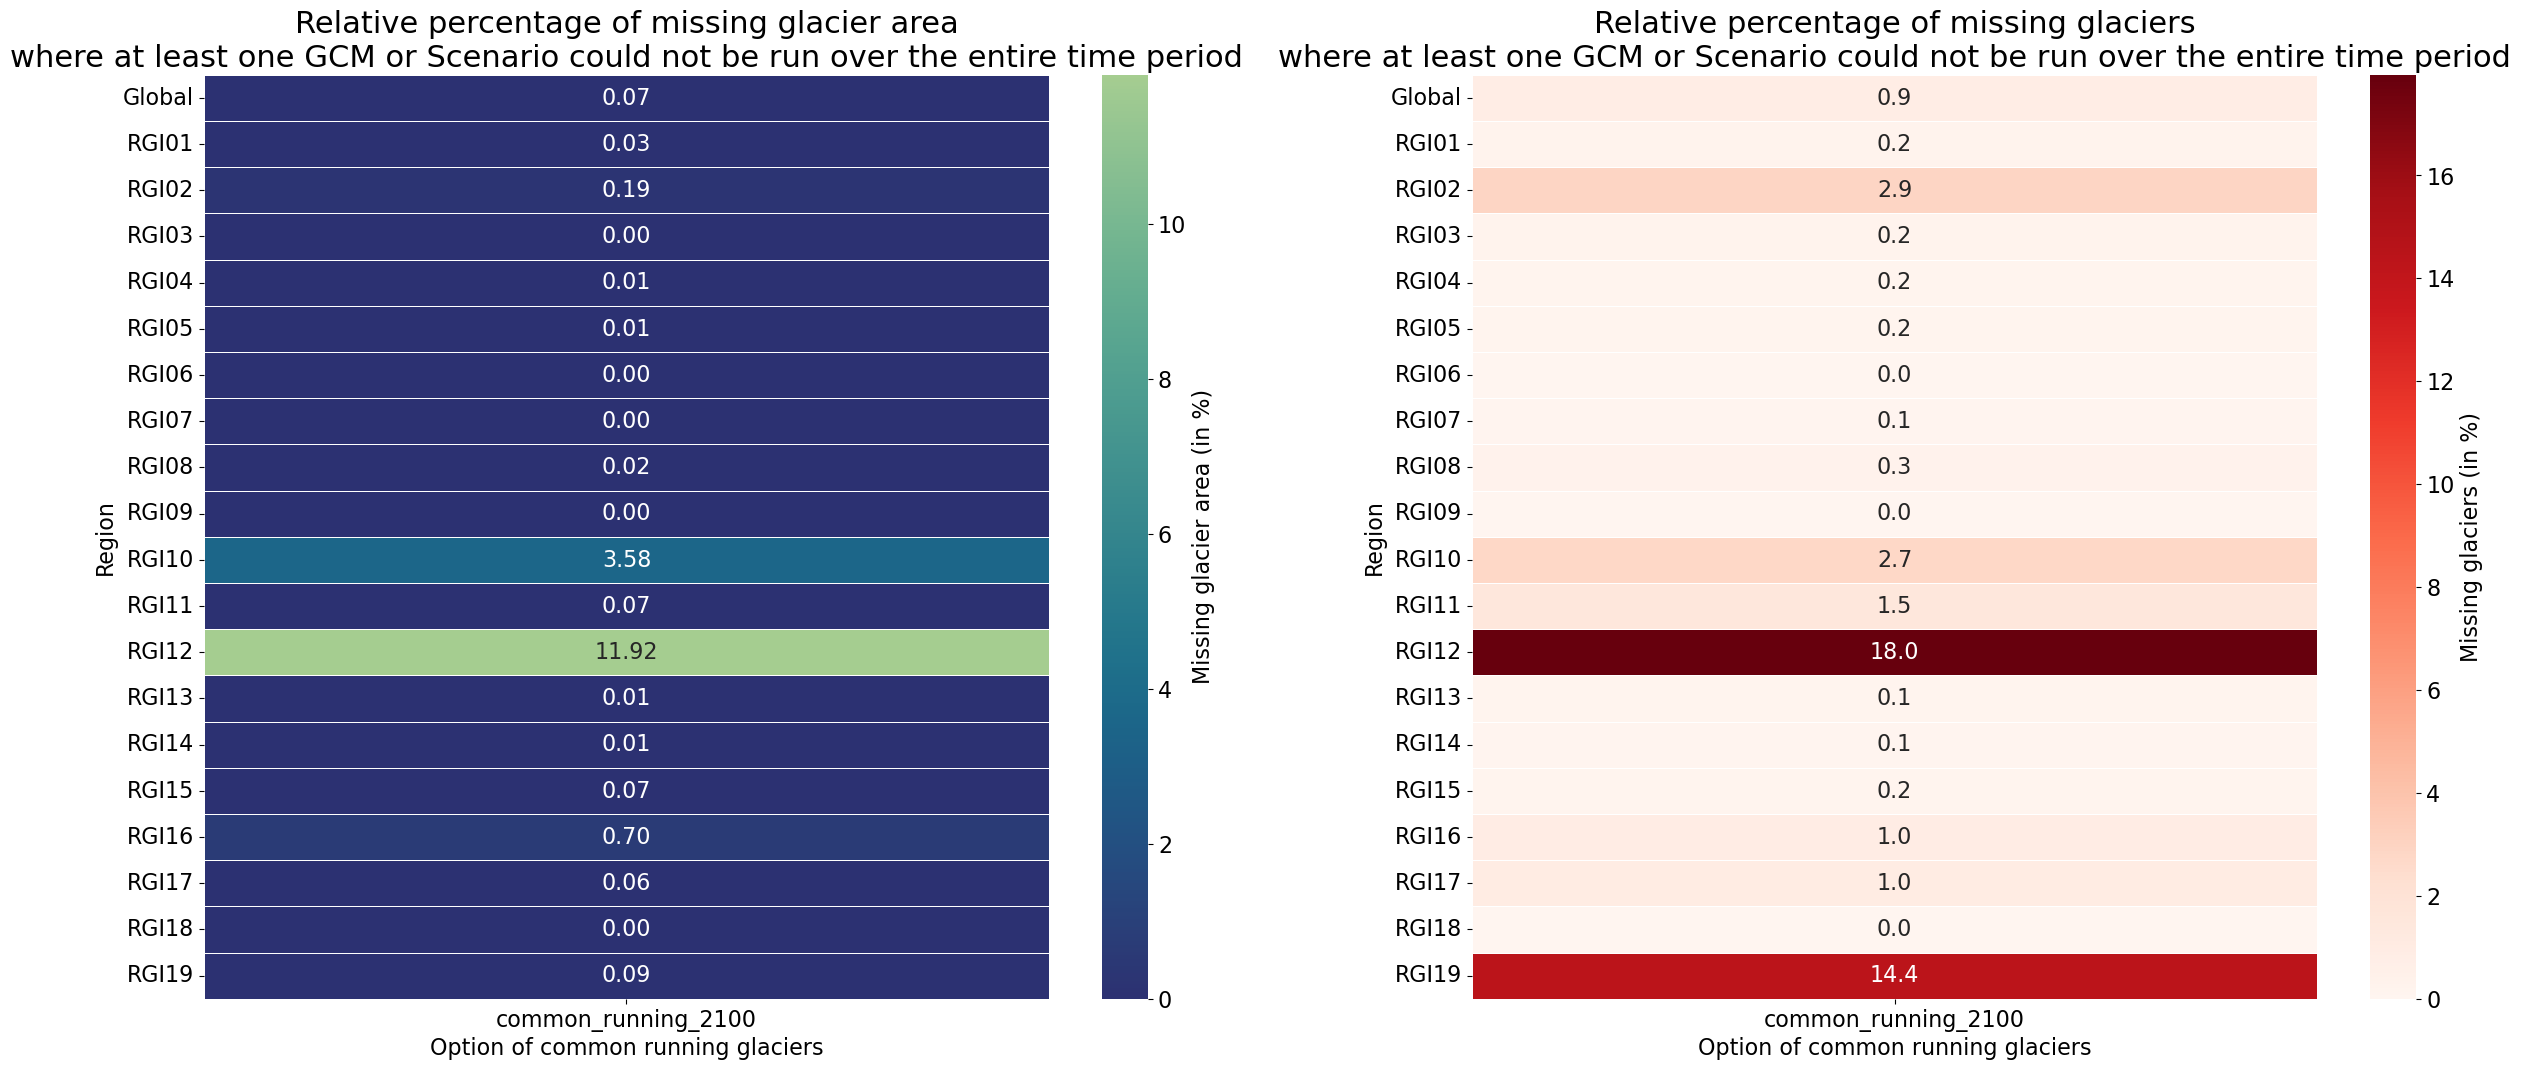

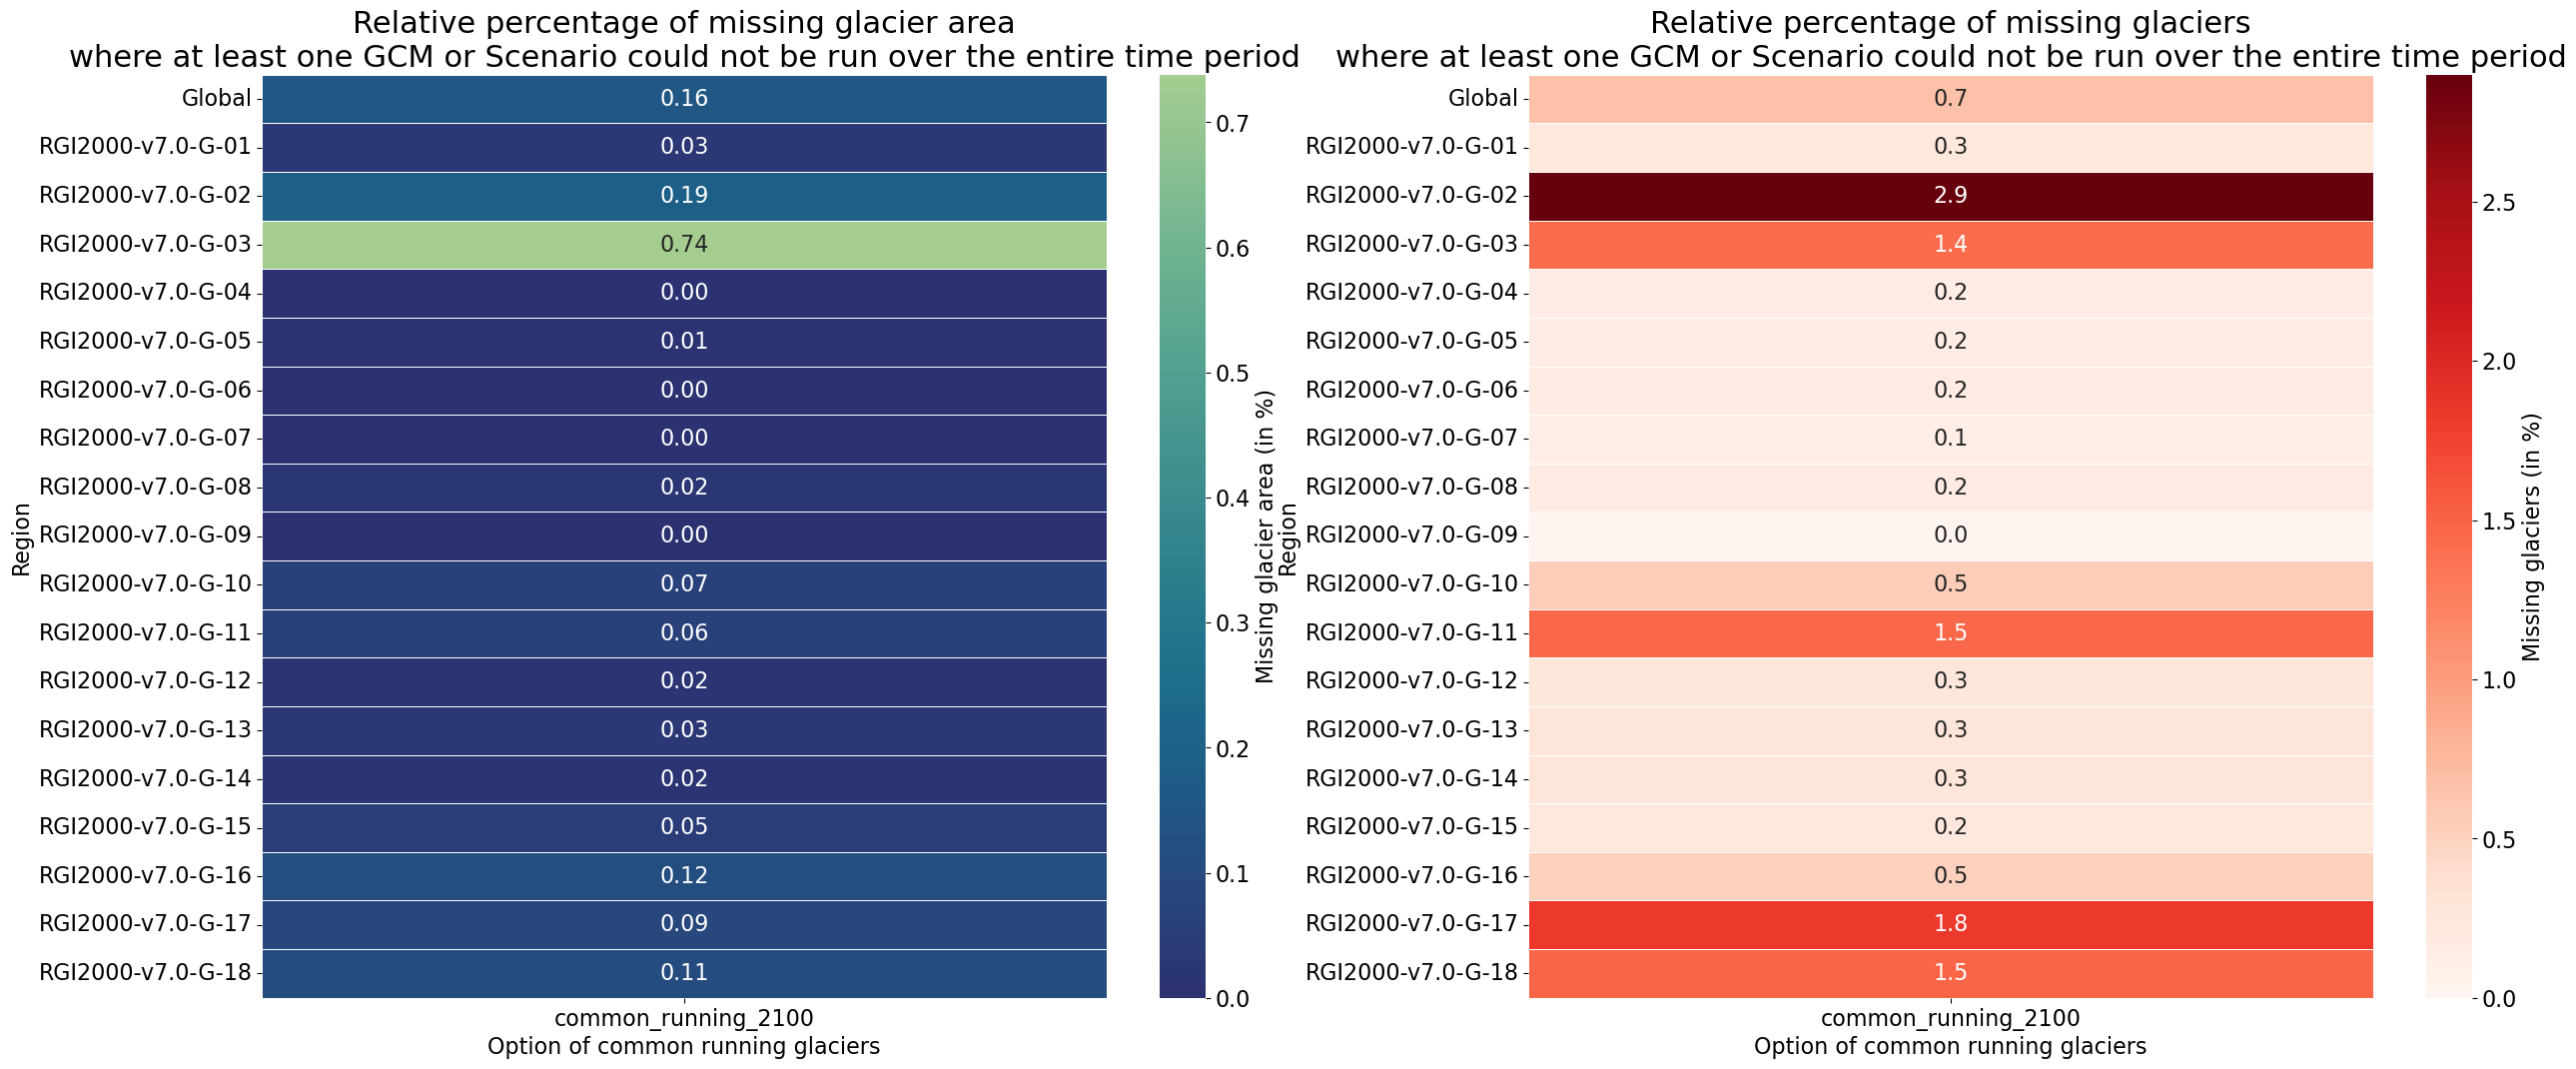

In [52]:
for _rgi_v in ['rgi62','rgi72G']:
    odf_2100= pd.read_csv(f'{outputpath}/common_running_2100/missing_region_overview_{_rgi_v}{add}.csv', index_col=0)
    odf_2100.loc['Global'] = odf_2100.sum(axis=0)
    # need to recompute the percentage
    odf_2100['missing_area_perc'] = 100*odf_2100['missing_area_km2'] / odf_2100['rgi_area_km2']
    odf_2100['missing_glaciers_perc'] = 100*odf_2100['n_missing_glaciers'] / odf_2100['n_glaciers']
    odf_2100 = odf_2100.sort_index()
    
    
    #odf_2300= pd.read_csv(f'{outputpath}/common_running_2100_2300/missing_region_overview.csv', index_col=0)
    #odf_2300.loc['Global'] = odf_2300.sum(axis=0)
    # need to recompute the percentage
    #odf_2300['missing_area_perc'] = 100*odf_2300['missing_area_km2'] / odf_2300['rgi_area_km2']
    #odf_2300['missing_glaciers_perc'] = 100*odf_2300['n_missing_glaciers'] / odf_2300['n_glaciers']
    #odf_2300 = odf_2300.sort_index()
    
    
    
    import seaborn as sns
    
    odf_area = odf_2100[['missing_area_perc']]
    odf_area.index.name = 'Region'
    odf_area.columns.name = 'Option of common running glaciers'
    odf_area = odf_area.rename(columns={'missing_area_perc':'common_running_2100'})
    #odf_area['common_running_2100_2300'] = odf_2300['missing_area_perc']
    
    odf_glac = odf_2100[['missing_glaciers_perc']]
    odf_glac.index.name = 'Region'
    odf_glac.columns.name = 'Option of common running glaciers'
    odf_glac = odf_glac.rename(columns={'missing_glaciers_perc':'common_running_2100'})
    #odf_glac['common_running_2100_2300'] = odf_2300['missing_glaciers_perc']
    
    
    plt.rc('font', size=16)
    fig, axs = plt.subplots(1,2,figsize=(30,12))
    ax = axs[0]
    sns.heatmap(odf_area.astype(float), 
                ax=ax,
                annot=True, fmt=".2f",cmap="crest_r",linewidth=.5,
                cbar_kws={'label':'Missing glacier area (in %)'})
    ax.set_title(f'Relative percentage of missing glacier area\nwhere at least one GCM or Scenario could not be run over the entire time period', fontsize=22)
    
    
    ax = axs[1]
    sns.heatmap(odf_glac.astype(float), annot=True, fmt=".1f",cmap="Reds",linewidth=.5, ax=ax,
                cbar_kws={'label':'Missing glaciers (in %)'})
    ax.set_title(f'Relative percentage of missing glaciers\nwhere at least one GCM or Scenario could not be run over the entire time period', fontsize=22);
    plt.savefig(f'missing_glacier_area_stats_{rgi_version}{add}.png')


### OLD

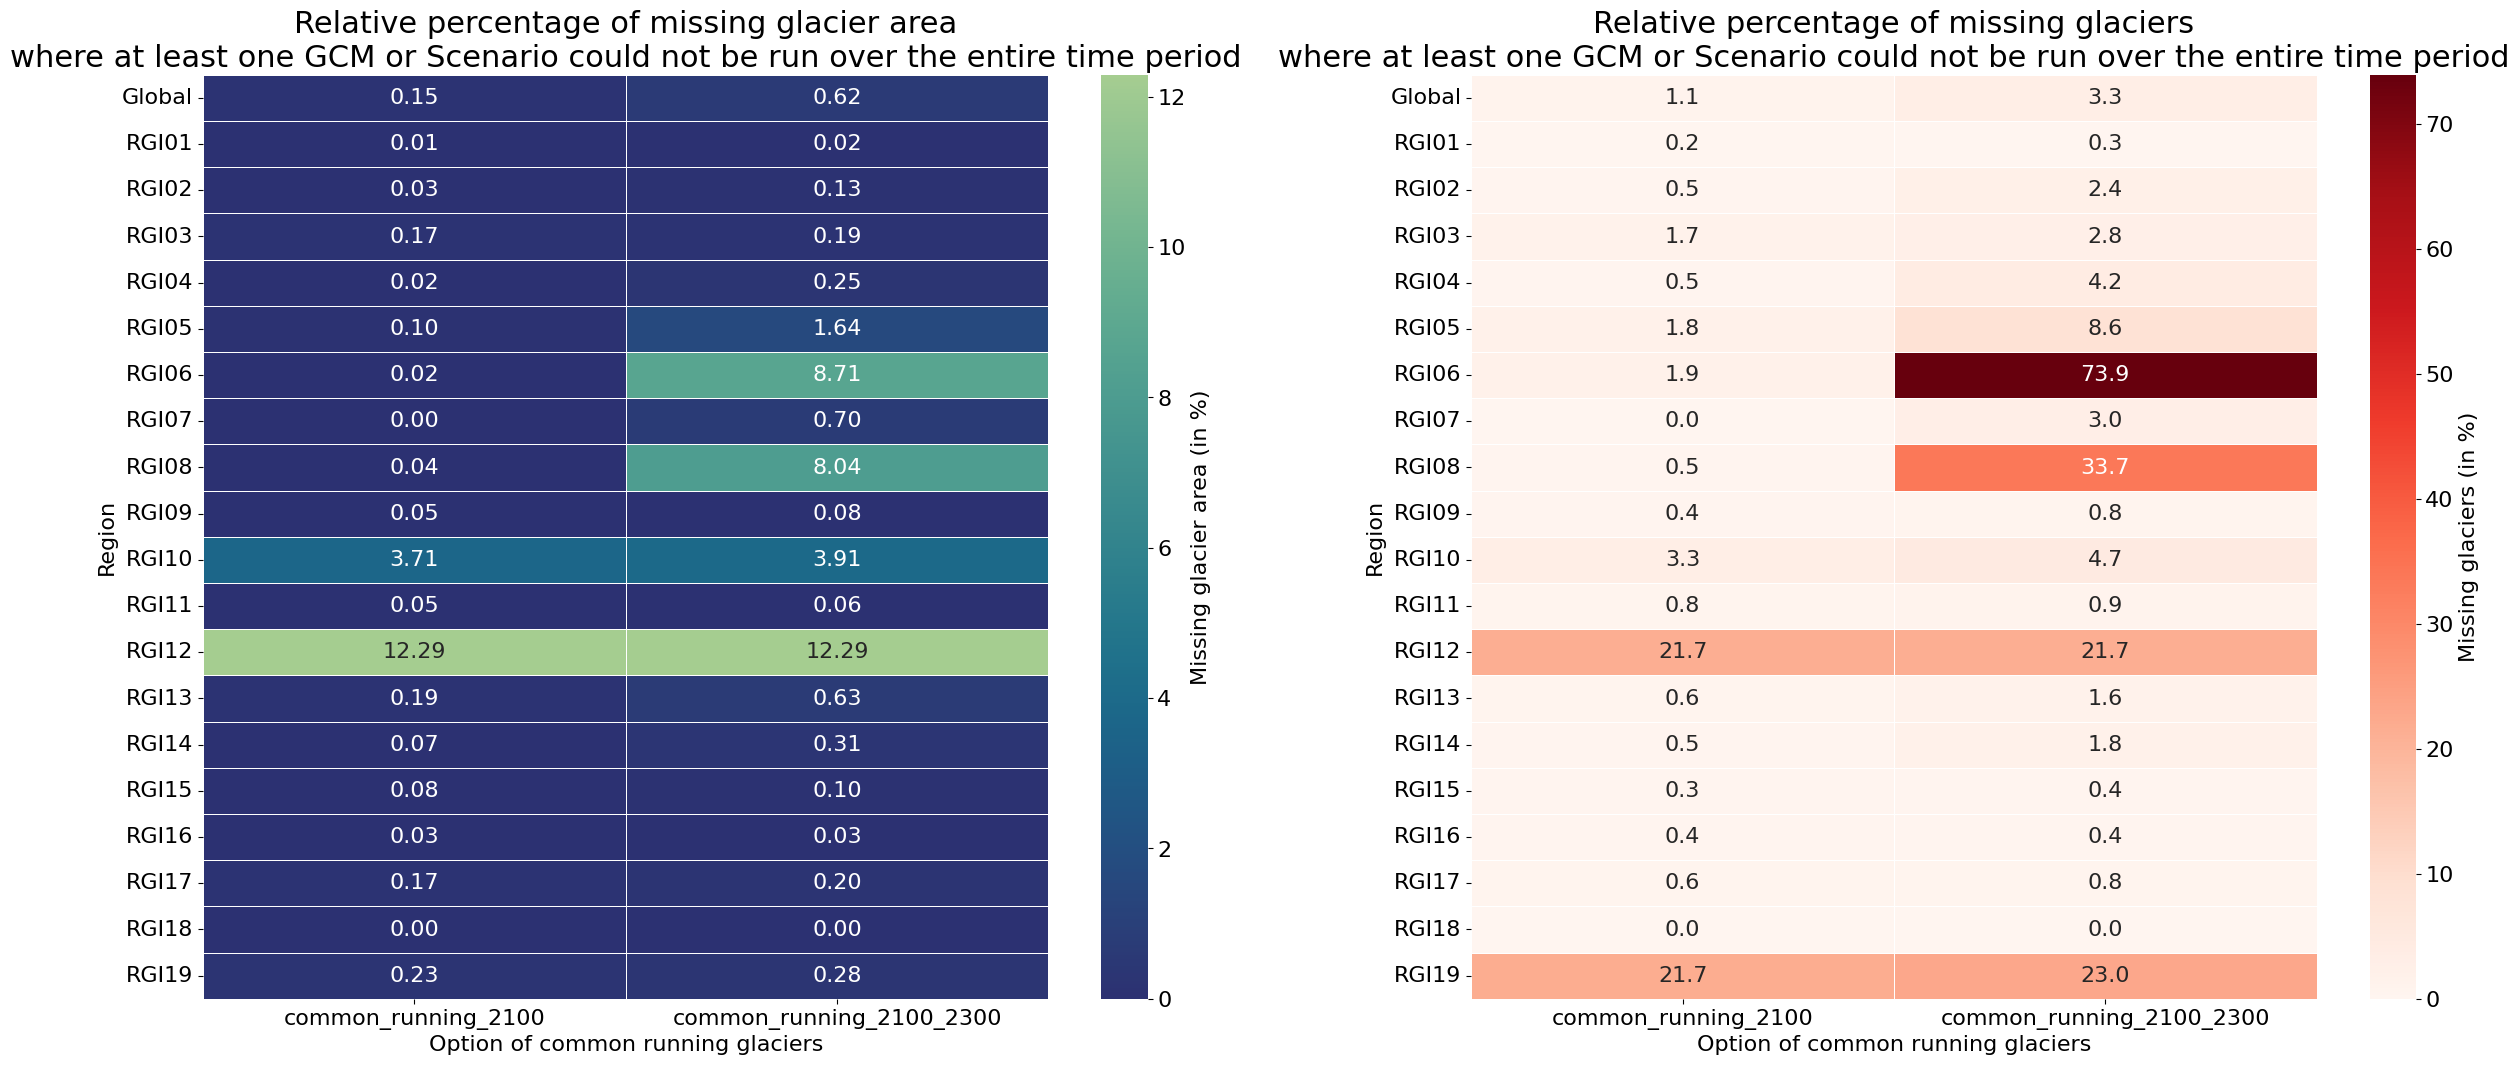

## Appendix
### C: common running with Rounce et al. (2023)

In [6]:
base_dir =f'/home/www/oggm/oggm-standard-projections/analysis_notebooks/1.6.1/common_running_rounce_et_al_2023'
df_meta = pd.read_csv(f'{outputpath}/common_running_2100/metadata.csv', index_col = 0)
import json
# this file has been created here: /home/www/oggm/oggm-standard-projections/oggm-standard-projections-csv-files/notebooks/analyse_csv_files_1.6.1.ipynb
with open(f'/home/www/oggm/oggm-standard-projections/analysis_notebooks/1.6.1/common_running_rounce_et_al_2023/rgi_ids_missing_rounce_et_al_or_oggm.json', 'r') as f:
    invalid_per_reg = json.load(f)

In [8]:
for cmip in ['CMIP6']:
    print(cmip, flush=True)
    if cmip == 'CMIP6':
        end_years = [2100]
    else:
        end_years = [2100]
    for end_year in end_years:
        for rgi_reg in sorted(df_meta.rgi_reg.unique()): #progressbar.progressbar(
            for scenario in ['ssp126', 'ssp245','ssp370', 'ssp585']:
                df_meta_s = df_meta.loc[(df_meta.end_year == end_year) & (df_meta.cmip == cmip) & (df_meta.rgi_reg == rgi_reg) & (df_meta.scenario == scenario)]
                odf_v = pd.DataFrame()
                odf_a = pd.DataFrame()
                ods = []
                gcms = []
                for i, s in df_meta_s.iterrows():
                    with xr.open_mfdataset(s.fpath) as ds:
                        ds = ds[['volume']].load().isel(rgi_id=~ds.rgi_id.isin(invalid_per_reg[s.rgi_reg]))
                        #ds = ds[['volume', 'area', 'length']].load().isel(rgi_id=~ds.rgi_id.isin(invalid_per_reg[s.rgi_reg]))
                        odf_v[s.gcm] = ds.volume.sum(dim='rgi_id').to_series()
                        ods.append(ds)
                        gcms.append(s.gcm)
                ods = xr.concat(ods, 'gcm')

                # I don't like to have these kind of summary statistics as the user does not know whether the different projections are gaussian distributed .. 
                #ods.mean(dim='gcm').to_netcdf(f'output_1.6.1_2023.3/{exp}/{rgi_reg}/all_gcm_avg_{scenario}.nc')
                #ods.std(dim='gcm').to_netcdf(f'output_1.6.1_2023.3/{exp}/{rgi_reg}/all_gcm_std_{scenario}.nc')
                odir =  f'{base_dir}/volume/{cmip}/{end_year}/{rgi_reg}/'
                mkdir(odir)
                odf_v.to_csv(odir + f'{scenario}.csv')


CMIP6


In [9]:
# globally: sum over all RGI regions
for var in ['volume']:
    for cmip in ['CMIP6']:
        if cmip == 'CMIP6':
            end_years = [2100]
        else:
            end_years = [2100]
        for end_year in end_years:
            odir = f'{base_dir}/{var}/{cmip}/{end_year}/global/'
            mkdir(odir)
            for scenario in ['ssp126', 'ssp245','ssp370', 'ssp585']:
                odf = 0
                for rgi_reg in sorted(df_meta.rgi_reg.unique()):
                    idir = f'{base_dir}/{var}/{cmip}/{end_year}/{rgi_reg}/'
                    df = pd.read_csv(idir + f'{scenario}.csv', index_col=0)
                    odf += df
                odf.to_csv(odir + f'{scenario}.csv')

In [10]:
df_meta

,cmip,gcm_original,gcm,scenario,rgi_reg,end_year,bias_correction,perc_area_missing,fpath,exp,historical_future_option,oggm_version
ISIMIP3b_CMIP6:2100:MRI-ESM2-0:ssp585:RGI11,ISIMIP3b_CMIP6,mri-esm2-0,MRI-ESM2-0,ssp585,RGI11,2100,ISIMIP3b:1979-2014,0.000495,/home/www/oggm/oggm-standard-projections/oggm_...,match_geod_pergla,w5e5_gcm_merged,oggm_v1.6.1_2023.3
ISIMIP3b_CMIP6:2100:UKESM1-0-LL:ssp585:RGI11,ISIMIP3b_CMIP6,ukesm1-0-ll,UKESM1-0-LL,ssp585,RGI11,2100,ISIMIP3b:1979-2014,0.000495,/home/www/oggm/oggm-standard-projections/oggm_...,match_geod_pergla,w5e5_gcm_merged,oggm_v1.6.1_2023.3
ISIMIP3b_CMIP6:2100:MRI-ESM2-0:ssp126:RGI11,ISIMIP3b_CMIP6,mri-esm2-0,MRI-ESM2-0,ssp126,RGI11,2100,ISIMIP3b:1979-2014,0.000495,/home/www/oggm/oggm-standard-projections/oggm_...,match_geod_pergla,w5e5_gcm_merged,oggm_v1.6.1_2023.3
ISIMIP3b_CMIP6:2100:UKESM1-0-LL:ssp370:RGI11,ISIMIP3b_CMIP6,ukesm1-0-ll,UKESM1-0-LL,ssp370,RGI11,2100,ISIMIP3b:1979-2014,0.000495,/home/www/oggm/oggm-standard-projections/oggm_...,match_geod_pergla,w5e5_gcm_merged,oggm_v1.6.1_2023.3
ISIMIP3b_CMIP6:2100:MRI-ESM2-0:ssp370:RGI11,ISIMIP3b_CMIP6,mri-esm2-0,MRI-ESM2-0,ssp370,RGI11,2100,ISIMIP3b:1979-2014,0.000495,/home/www/oggm/oggm-standard-projections/oggm_...,match_geod_pergla,w5e5_gcm_merged,oggm_v1.6.1_2023.3
...,...,...,...,...,...,...,...,...,...,...,...,...
CMIP5:2100:GFDL-CM3:rcp45:RGI04,CMIP5,GFDL-CM3,GFDL-CM3,rcp45,RGI04,2100,2000-2019,0.000053,/home/www/oggm/oggm-standard-projections/oggm_...,match_geod_pergla,w5e5_gcm_merged,oggm_v1.6.1_2023.3
CMIP5:2100:CSIRO-MK3-6-0:rcp26:RGI04,CMIP5,CSIRO-Mk3-6-0,CSIRO-MK3-6-0,rcp26,RGI04,2100,2000-2019,0.000073,/home/www/oggm/oggm-standard-projections/oggm_...,match_geod_pergla,w5e5_gcm_merged,oggm_v1.6.1_2023.3
CMIP5:2100:IPSL-CM5A-LR:rcp45:RGI04,CMIP5,IPSL-CM5A-LR,IPSL-CM5A-LR,rcp45,RGI04,2100,2000-2019,0.000063,/home/www/oggm/oggm-standard-projections/oggm_...,match_geod_pergla,w5e5_gcm_merged,oggm_v1.6.1_2023.3
CMIP5:2100:GFDL-CM3:rcp85:RGI04,CMIP5,GFDL-CM3,GFDL-CM3,rcp85,RGI04,2100,2000-2019,0.000053,/home/www/oggm/oggm-standard-projections/oggm_...,match_geod_pergla,w5e5_gcm_merged,oggm_v1.6.1_2023.3
